In [27]:
import os, sys

import time
import random
from pprint import pprint
from glob import glob
import numpy as np
import pickle
import matplotlib.pyplot as plt
import cv2
from matplotlib.patches import FancyArrowPatch
import pandas as pd


import pygarment as pyg
import trimesh
import PIL
from PIL import Image

from analysis_utils import visualize_meshes_plotly, v_id_map, plot_panel_info

sys.path.append(
    os.path.dirname(os.getcwd())
)

from env_constants import PYGARMENT_ROOT, DATASET_ROOT

GARMENT_ROOT_PATH = os.path.join(
    DATASET_ROOT, 'GarmentCodeData_v2'
)


In [16]:
IDX = 1000
# BODY_TYPE = "random_body"
BODY_TYPE = "default_body"

garment_path_list = sorted(list(filter(
    os.path.isdir,
    glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
)))

garment_path = garment_path_list[IDX]
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0BD28UCVO8"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0AAY3NQH8J"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_3/default_body/rand_005ZYVMOCL"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0A36YXPNV0"

garment_id = os.path.basename(garment_path)
SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")
pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)
drawn_pattern_list = list(map(
    lambda pannel_name : pattern._draw_a_panel(
        pannel_name, apply_transform=False, fill=True
    ),
    pattern.panel_order()
))
panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order()
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}

In [26]:
for panel_name, panel_info in panel_svg_path_dict.items():
    for edge_idx, edge_info in enumerate(panel_info[0]) :
        stt = np.array([edge_info.start.real, edge_info.start.imag])
        end = np.array([edge_info.end.real, edge_info.end.imag])
        print(end - stt)


[-6.8341735   0.19323641]
[ -1.65275996 -11.88972114]
[-0.12283287 12.00341603]
[-4.53974674  0.41045438]
[ -2.13326856 -10.59093025]
[ 0.3660641  10.79743651]
[-8.20964081  1.44499972]
[ -0.71169167 -14.23386667]
[ 0.         -4.61345071]
[  6.60965 -18.44148]
[ 6.4096     -2.54780061]
[10.8188     10.03441366]
[ 0.         27.43329266]
[  0.         -31.49732657]
[-10.8188     -12.00827124]
[-6.24979332  2.48427726]
[-7.39249546 18.44148   ]
[-1.62121122  4.6769739 ]
[13.07883125  1.8345    ]
[-13.07883125   1.8345    ]
[ 1.1611     14.23386664]
[14.12584987  0.        ]
[  1.1611     -12.75775233]
[ 1.1611     12.75775233]
[8.47315013 0.        ]
[ 0. -7.]
[16.22647564  0.        ]
[0. 7.]
[-16.22647564   0.        ]
[18.21927418  0.        ]
[ 0. -7.]
[-18.21927418   0.        ]
[0. 7.]
[  0.         -27.43329266]
[ 10.8188     -10.03441366]
[6.4096     2.54780061]
[ 6.60965 18.44148]
[0.         4.61345071]
[-0.71169167 14.23386667]
[-8.20964081 -1.44499972]
[  0.3660641  -10.7974

In [36]:
panel_info[0]

Path(Line(start=(18.219274177041996+7j), end=(18.219274177041996+0j)),
     Line(start=(18.219274177041996+0j), end=0j),
     Line(start=0j, end=7j),
     Line(start=7j, end=(18.219274177041996+7j)))

In [37]:
gcd_metadata = pd.read_csv(os.path.join(
    PYGARMENT_ROOT, "garment_code_data_meta_df.csv"
))

gcd_metadata

,garment_path,split,garment_id,max_token_length,drape_failed,has_digit_in_panel_name,panel_count
0,garments_5000_0/default_body/rand_RVS1QWPXD0,test,rand_RVS1QWPXD0,815,False,False,14
1,garments_5000_0/default_body/rand_M4Z0YOEJ6V,test,rand_M4Z0YOEJ6V,1123,False,False,16
2,garments_5000_0/default_body/rand_E489IFV849,test,rand_E489IFV849,774,False,False,20
3,garments_5000_0/default_body/rand_TNYM41T44B,test,rand_TNYM41T44B,484,False,False,8
4,garments_5000_0/default_body/rand_H1HW5UW5S7,test,rand_H1HW5UW5S7,1100,False,False,22
...,...,...,...,...,...,...,...
115190,garments_5000_35/default_body/rand_U7D7P03PKC,valid,rand_U7D7P03PKC,830,False,True,14
115191,garments_5000_35/default_body/rand_FHFVUV6ZZI,valid,rand_FHFVUV6ZZI,474,False,True,9
115192,garments_5000_35/default_body/rand_4MCUZ6H8DY,valid,rand_4MCUZ6H8DY,341,False,False,4
115193,garments_5000_35/default_body/rand_7748RZT21S,valid,rand_7748RZT21S,1057,False,True,12


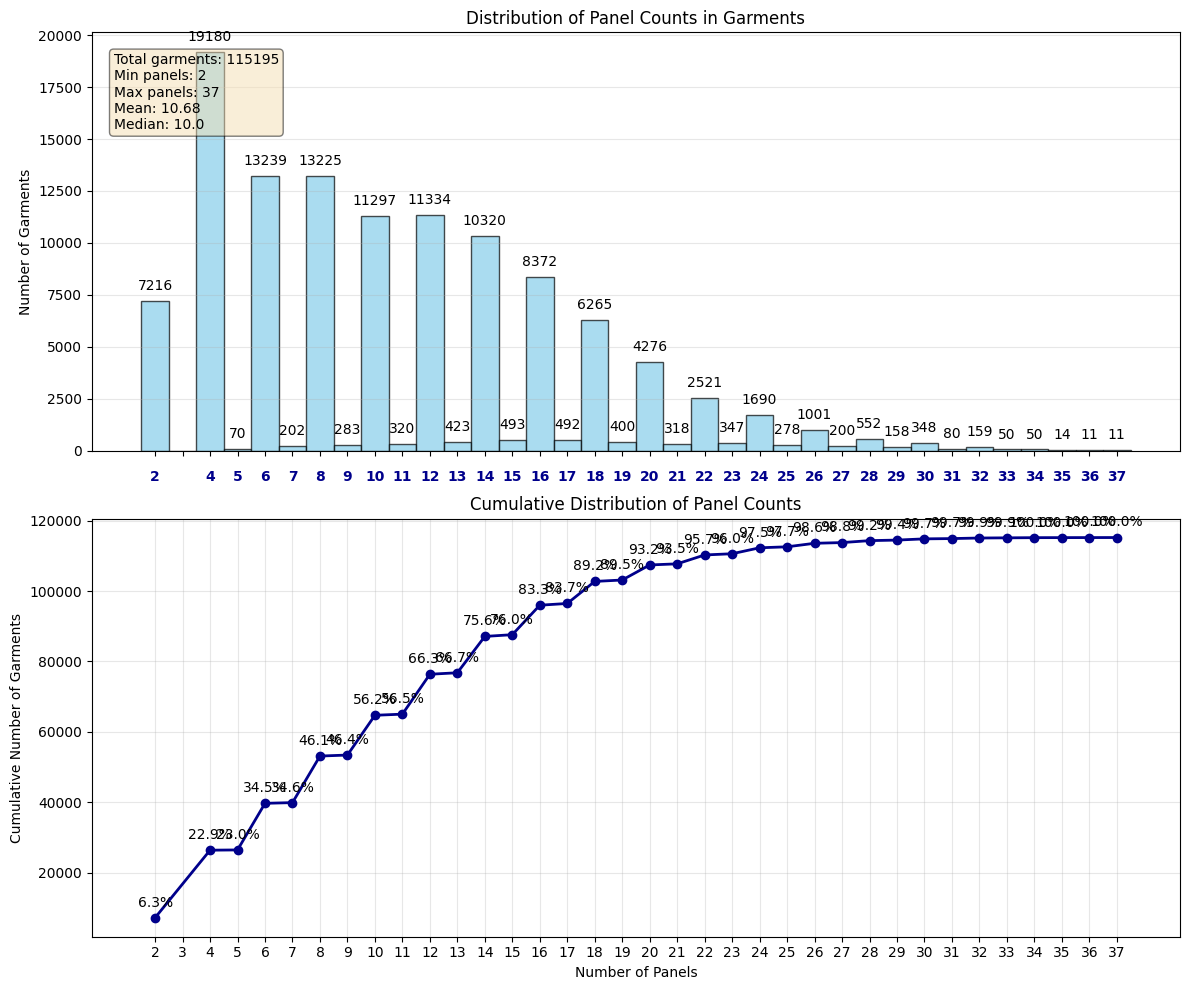

Panel count distribution summary:
Panel count 2: 7216 garments (6.3%), Cumulative: 7216 (6.3%)
Panel count 4: 19180 garments (16.7%), Cumulative: 26396 (22.9%)
Panel count 5: 70 garments (0.1%), Cumulative: 26466 (23.0%)
Panel count 6: 13239 garments (11.5%), Cumulative: 39705 (34.5%)
Panel count 7: 202 garments (0.2%), Cumulative: 39907 (34.6%)
Panel count 8: 13225 garments (11.5%), Cumulative: 53132 (46.1%)
Panel count 9: 283 garments (0.2%), Cumulative: 53415 (46.4%)
Panel count 10: 11297 garments (9.8%), Cumulative: 64712 (56.2%)
Panel count 11: 320 garments (0.3%), Cumulative: 65032 (56.5%)
Panel count 12: 11334 garments (9.8%), Cumulative: 76366 (66.3%)
Panel count 13: 423 garments (0.4%), Cumulative: 76789 (66.7%)
Panel count 14: 10320 garments (9.0%), Cumulative: 87109 (75.6%)
Panel count 15: 493 garments (0.4%), Cumulative: 87602 (76.0%)
Panel count 16: 8372 garments (7.3%), Cumulative: 95974 (83.3%)
Panel count 17: 492 garments (0.4%), Cumulative: 96466 (83.7%)
Panel count 18

In [35]:
# Create histogram and cumulative distribution plot for panel counts
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

panel_counts = gcd_metadata['panel_count']
min_count = min(panel_counts)
max_count = max(panel_counts)

bins = range(min_count, max_count + 2)
bin_centers = range(min_count, max_count + 1)

counts, edges, bars = ax1.hist(
    panel_counts,
    bins=bins,
    align='left',
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)

for i, count in enumerate(counts):
    if count > 0:  # Only add labels for bars with data
        ax1.text(bin_centers[i], count + (max(counts) * 0.02), 
                 str(int(count)), ha='center', va='bottom')
        ax1.text(bin_centers[i], -max(counts) * 0.05, 
                 str(bin_centers[i]), ha='center', va='top', 
                 fontweight='bold', color='darkblue')



ax1.set_ylabel('Number of Garments')
ax1.set_title('Distribution of Panel Counts in Garments')
ax1.grid(axis='y', alpha=0.3)


sorted_counts = np.sort(panel_counts)
cumulative_counts = np.arange(1, len(sorted_counts) + 1)


cumulative_dict = {}
for count, cum_count in zip(sorted_counts, cumulative_counts):
    cumulative_dict[count] = cum_count

# Get cumulative count for each unique panel count
unique_counts = sorted(set(panel_counts))
cum_values = [cumulative_dict[count] for count in unique_counts]

# Cumulative plot on the second subplot
ax2.plot(unique_counts, cum_values, 'o-', color='darkblue', linewidth=2, markersize=6)
ax2.set_xlabel('Number of Panels')
ax2.set_ylabel('Cumulative Number of Garments')
ax2.set_title('Cumulative Distribution of Panel Counts')
ax2.grid(True, alpha=0.3)

# Set x-ticks to show every integer value
plt.xticks(bin_centers)

# Add percentage labels to cumulative plot
total_garments = len(panel_counts)
for x, y in zip(unique_counts, cum_values):
    percentage = (y / total_garments) * 100
    ax2.text(x, y + (max(cum_values) * 0.02), 
             f"{percentage:.1f}%", ha='center', va='bottom')

# Add some statistics as text
stats_text = (f"Total garments: {total_garments}\n"
              f"Min panels: {min_count}\n"
              f"Max panels: {max_count}\n"
              f"Mean: {np.mean(panel_counts):.2f}\n"
              f"Median: {np.median(panel_counts):.1f}")

# Add text box with statistics
ax1.text(0.02, 0.95, stats_text, transform=ax1.transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary of panel count distribution
print(f"Panel count distribution summary:")
for count in sorted(set(panel_counts)):
    num_garments = list(panel_counts).count(count)
    cum_garments = sum(1 for p in panel_counts if p <= count)
    cum_percent = (cum_garments / total_garments) * 100
    print(f"Panel count {count}: {num_garments} garments ({num_garments/total_garments*100:.1f}%), "
          f"Cumulative: {cum_garments} ({cum_percent:.1f}%)")

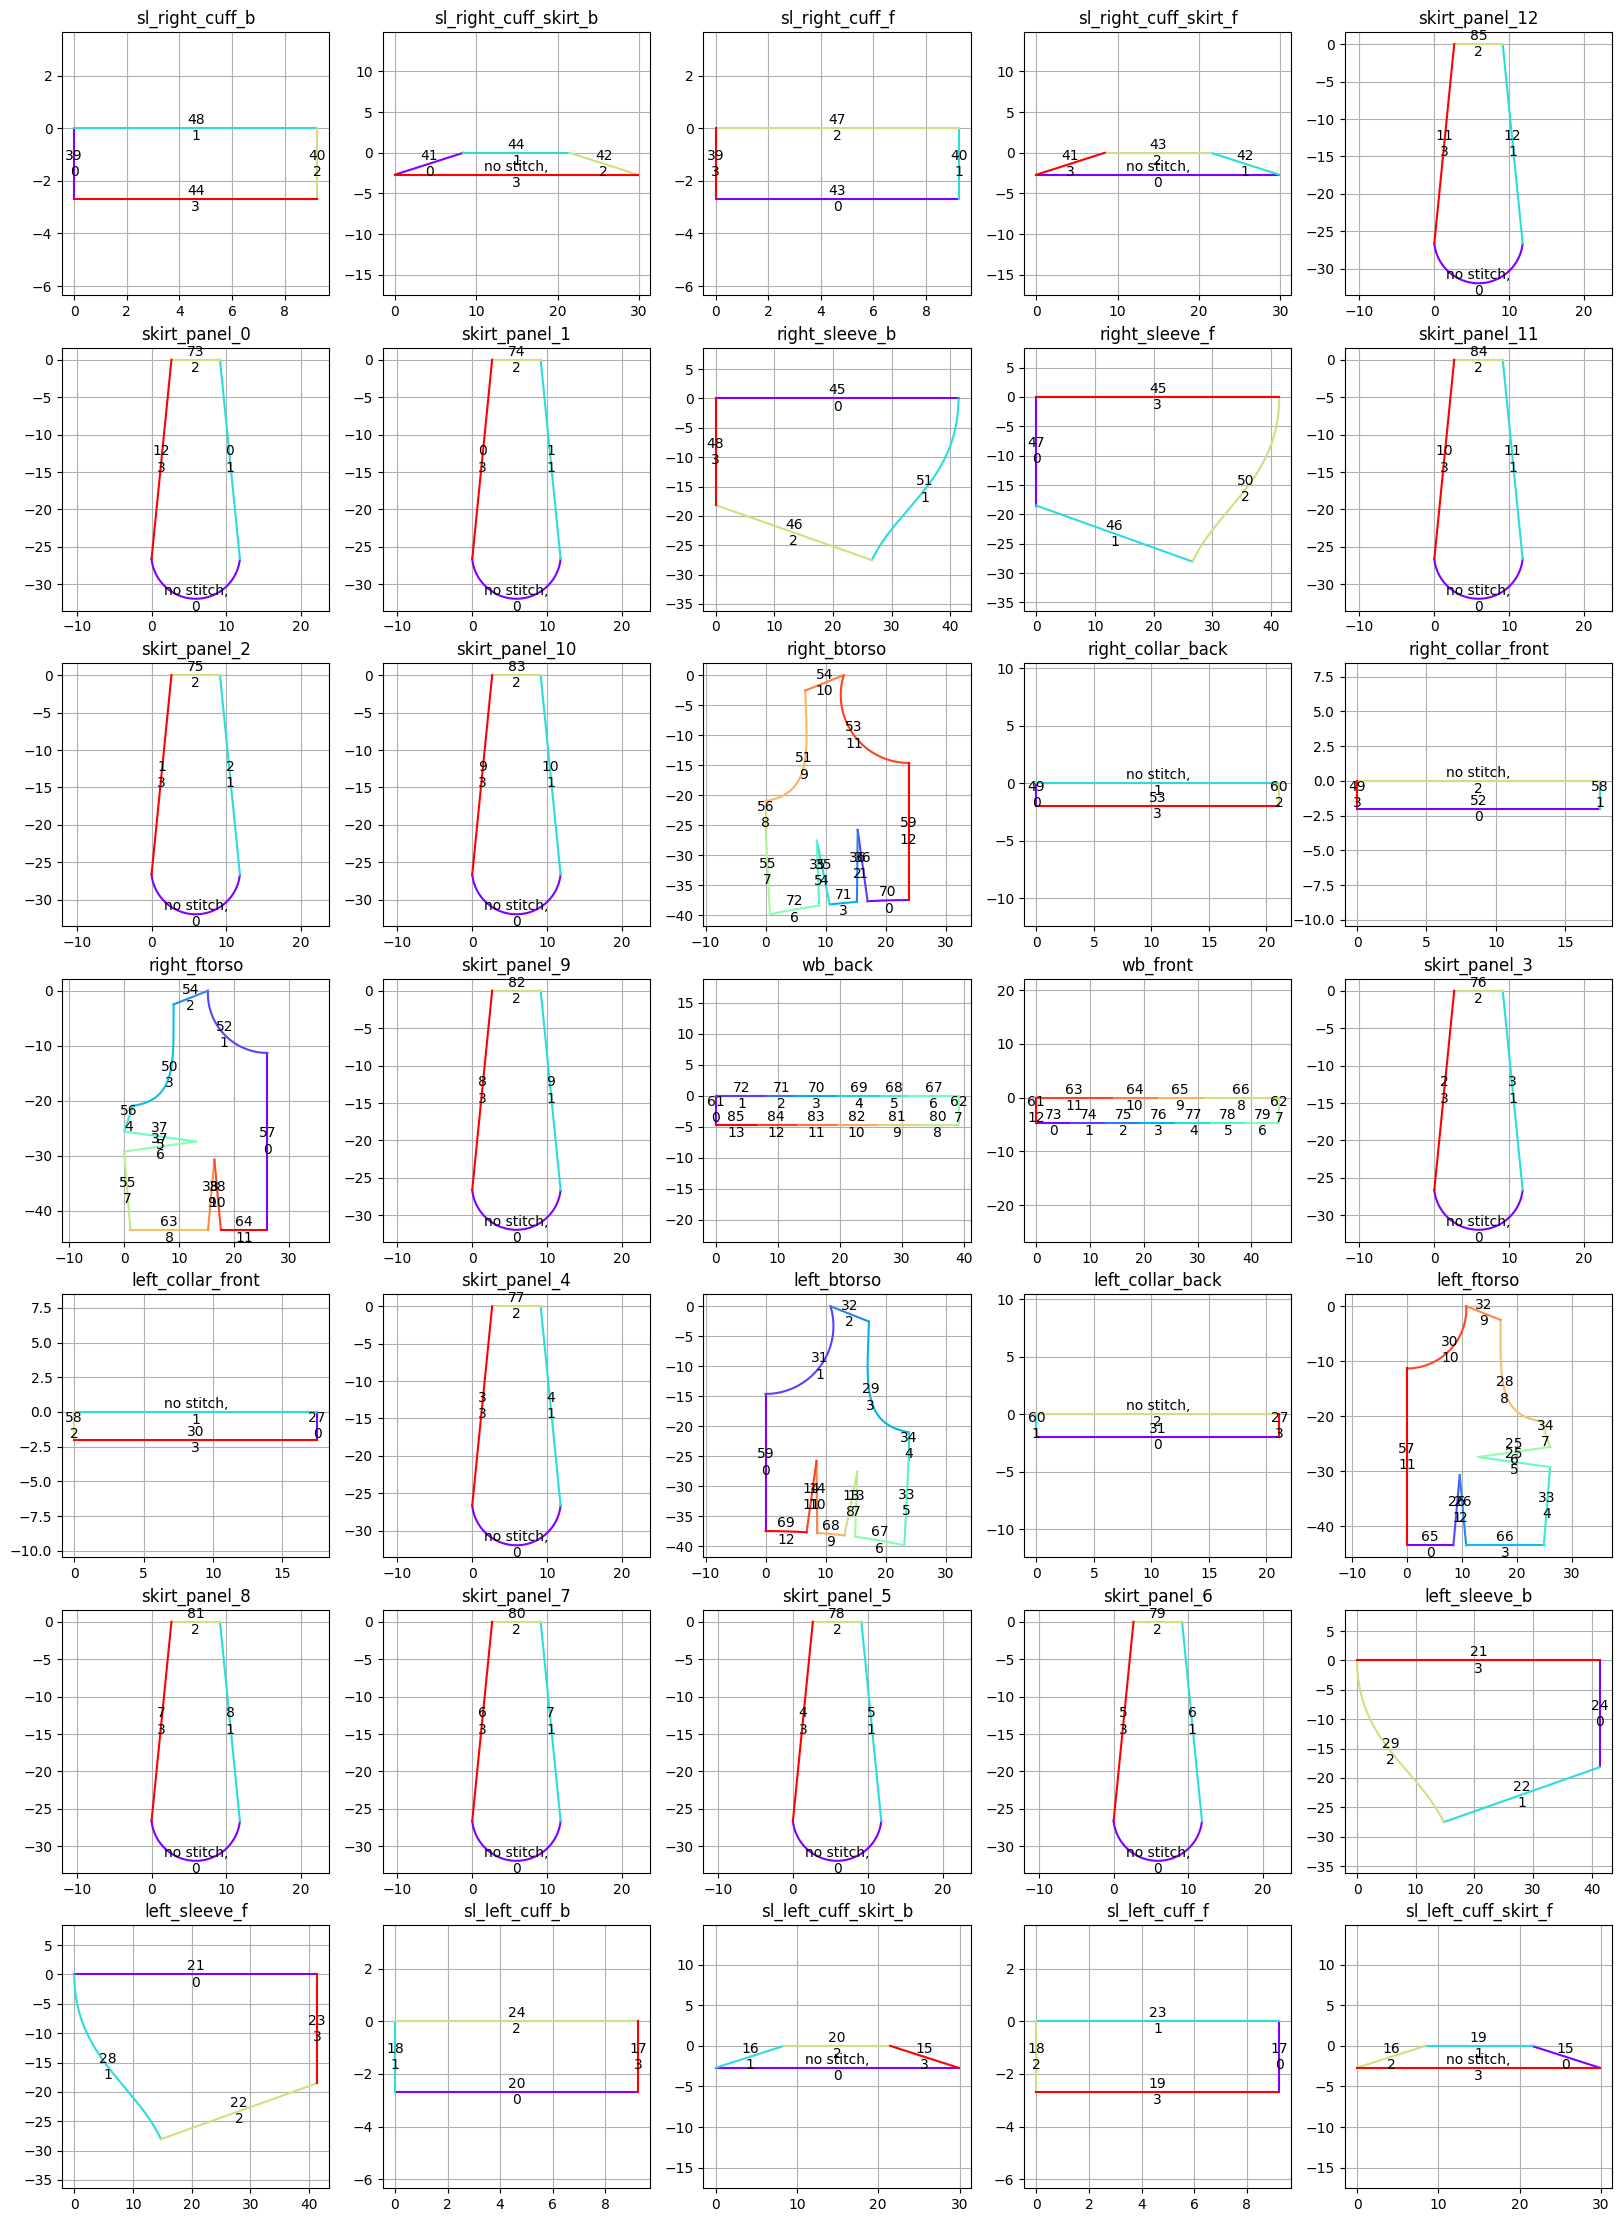

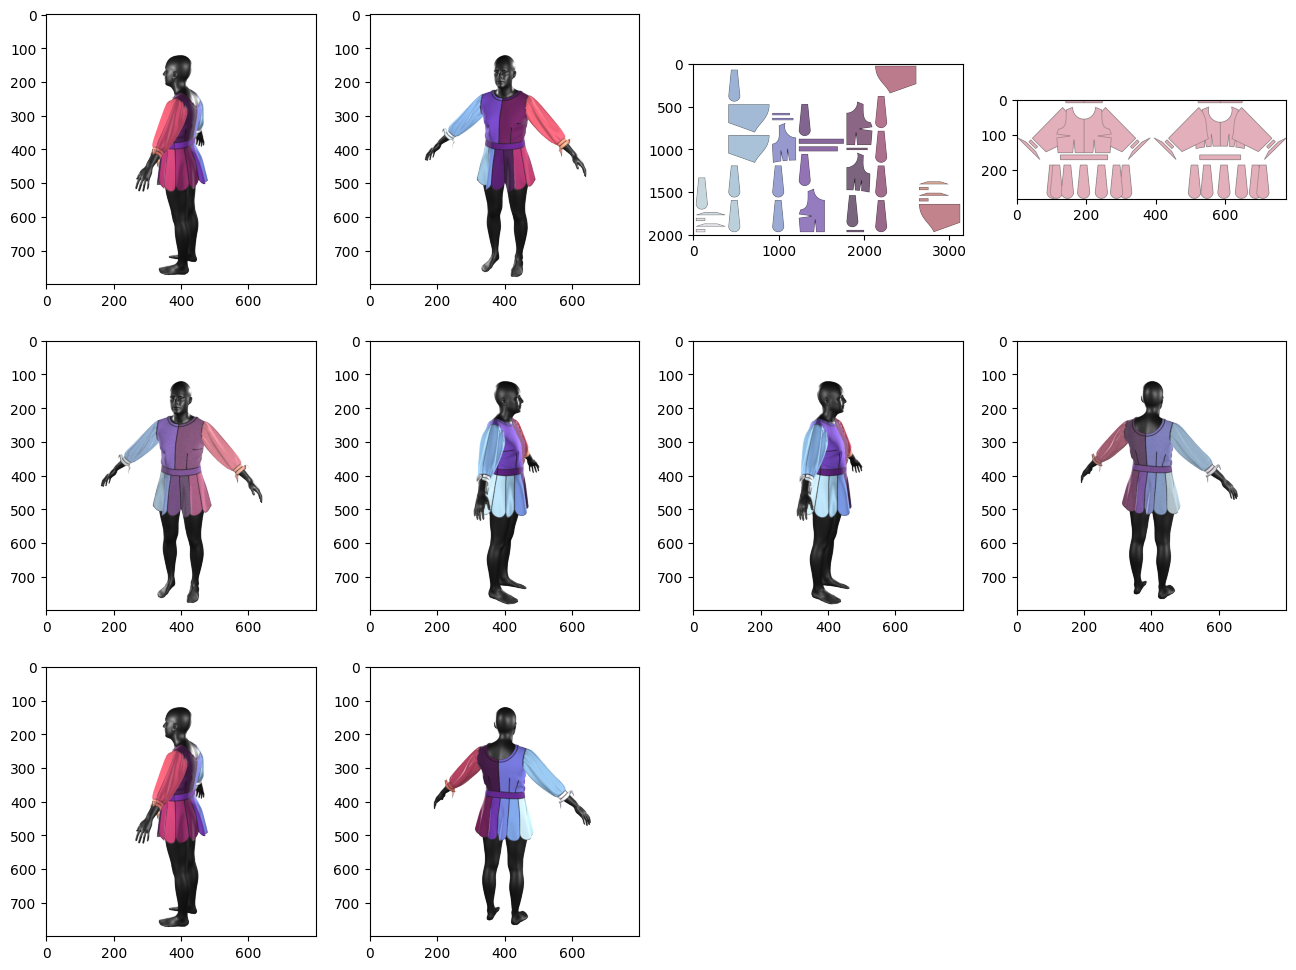

In [62]:
# =============================
GARMENT_COUNT = 35
# =============================

tmp_garment_path_list = gcd_metadata[gcd_metadata['panel_count'] == GARMENT_COUNT].garment_path.tolist()

# =============================
IDX = random.randint(0, len(tmp_garment_path_list) - 1)
# =============================

garment_path = os.path.join(
    GARMENT_ROOT_PATH, tmp_garment_path_list[IDX]
)
garment_id = os.path.basename(garment_path)
SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")
pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)


panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order()
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}



FIGLEN = 4
NCOLS = int(np.sqrt(len(panel_svg_path_dict)))
NROWS = int(np.ceil(len(panel_svg_path_dict) / NCOLS))

plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
for i, (panel_name, panel) in enumerate(panel_svg_path_dict.items()):
    ax = plt.subplot(NROWS, NCOLS, i + 1)
    ax.set_title(panel_name)
    plot_panel_info(
        ax, panel_name, panel_svg_path_dict, stitch_dict,
        N_SAMPLES=1000
    )
# plt.savefig(f"{garment_id}_panel_vis.png")
plt.show()

rendered_image_list = []
for image_path in glob(os.path.join(garment_path, "*.png")):
    rendered_image_list.append(
        Image.open(image_path)
    )
NROWS = int(np.sqrt(len(rendered_image_list)))
NCOLS = int(np.ceil(len(rendered_image_list) / NROWS))

plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
for i, rendered_image in enumerate(rendered_image_list):
    ax = plt.subplot(NROWS, NCOLS, i + 1)
    ax.imshow(rendered_image)